# Milestone 1: Formula 1 Podium Prediction Pipeline

## Phase 1: Environment Setup & Raw Data Auditing
- **Goal:** Load the relational Ergast F1 dataset across all 14 tables, verify schema structure, and perform an initial "before-cleaning" audit.
- **Unit of Analysis:** One driver entering one race (`raceId`, `driverId`).
- **Prediction Target:** Podium finish (`positionOrder <= 3`).
- **Prediction Cutoff:** After qualifying, before race start. Post-race metrics (race outcome, laps, pit stops, fastest lap, race points) are strictly restricted from feature sets to prevent data leakage.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting theme & styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# Configure pandas display limits
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

SENTINEL = r"\N"

In [2]:
# Adjust DATA_PATH to where your CSVs are stored (e.g., './tables' or './data')
DATA_PATH = "./tables"

TABLE_NAMES = [
    "circuits", "constructors", "constructor_results", "constructor_standings",
    "drivers", "driver_standings", "lap_times", "pit_stops", "qualifying",
    "races", "results", "seasons", "sprint_results", "status"
]

# Read all files as strings initially to prevent premature type coercion
raw_tables = {
    name: pd.read_csv(os.path.join(DATA_PATH, f"{name}.csv"), dtype=str, keep_default_na=False)
    for name in TABLE_NAMES
}

# Display row and column counts
for name, df in raw_tables.items():
    print(f"{name:25s} | Rows: {len(df):7d} | Cols: {df.shape[1]:2d}")

circuits                  | Rows:      77 | Cols:  9
constructors              | Rows:     212 | Cols:  5
constructor_results       | Rows:   12625 | Cols:  5
constructor_standings     | Rows:   13391 | Cols:  7
drivers                   | Rows:     861 | Cols:  9
driver_standings          | Rows:   34863 | Cols:  7
lap_times                 | Rows:  589081 | Cols:  6
pit_stops                 | Rows:   11371 | Cols:  7
qualifying                | Rows:   10494 | Cols:  9
races                     | Rows:    1125 | Cols: 18
results                   | Rows:   26759 | Cols: 18
seasons                   | Rows:      75 | Cols:  2
sprint_results            | Rows:     360 | Cols: 16
status                    | Rows:     139 | Cols:  2


In [3]:
def generate_sentinel_report(df, name):
    sentinel_counts = (df == SENTINEL).sum()
    empty_counts = df.isna().sum()
    total_missing = sentinel_counts + empty_counts
    pct_missing = (100 * (total_missing / len(df))).round(2)
    
    report = pd.DataFrame({
        "table": name,
        "sentinel_\\N": sentinel_counts,
        "empty_cells": empty_counts,
        "total_missing": total_missing,
        "pct_missing": pct_missing
    })
    return report[report["total_missing"] > 0]

all_missing = []
for name, df in raw_tables.items():
    rep = generate_sentinel_report(df, name)
    if not rep.empty:
        all_missing.append(rep)

missing_summary = pd.concat(all_missing)
display(missing_summary)

,table,sentinel_\N,empty_cells,total_missing,pct_missing
status,constructor_results,12608,0,12608,99.87
number,drivers,802,0,802,93.15
code,drivers,757,0,757,87.92
q1,qualifying,156,0,156,1.49
q2,qualifying,4625,0,4625,44.07
q3,qualifying,6819,0,6819,64.98
time,races,731,0,731,64.98
fp1_date,races,1035,0,1035,92.00
fp1_time,races,1057,0,1057,93.96
fp2_date,races,1035,0,1035,92.00


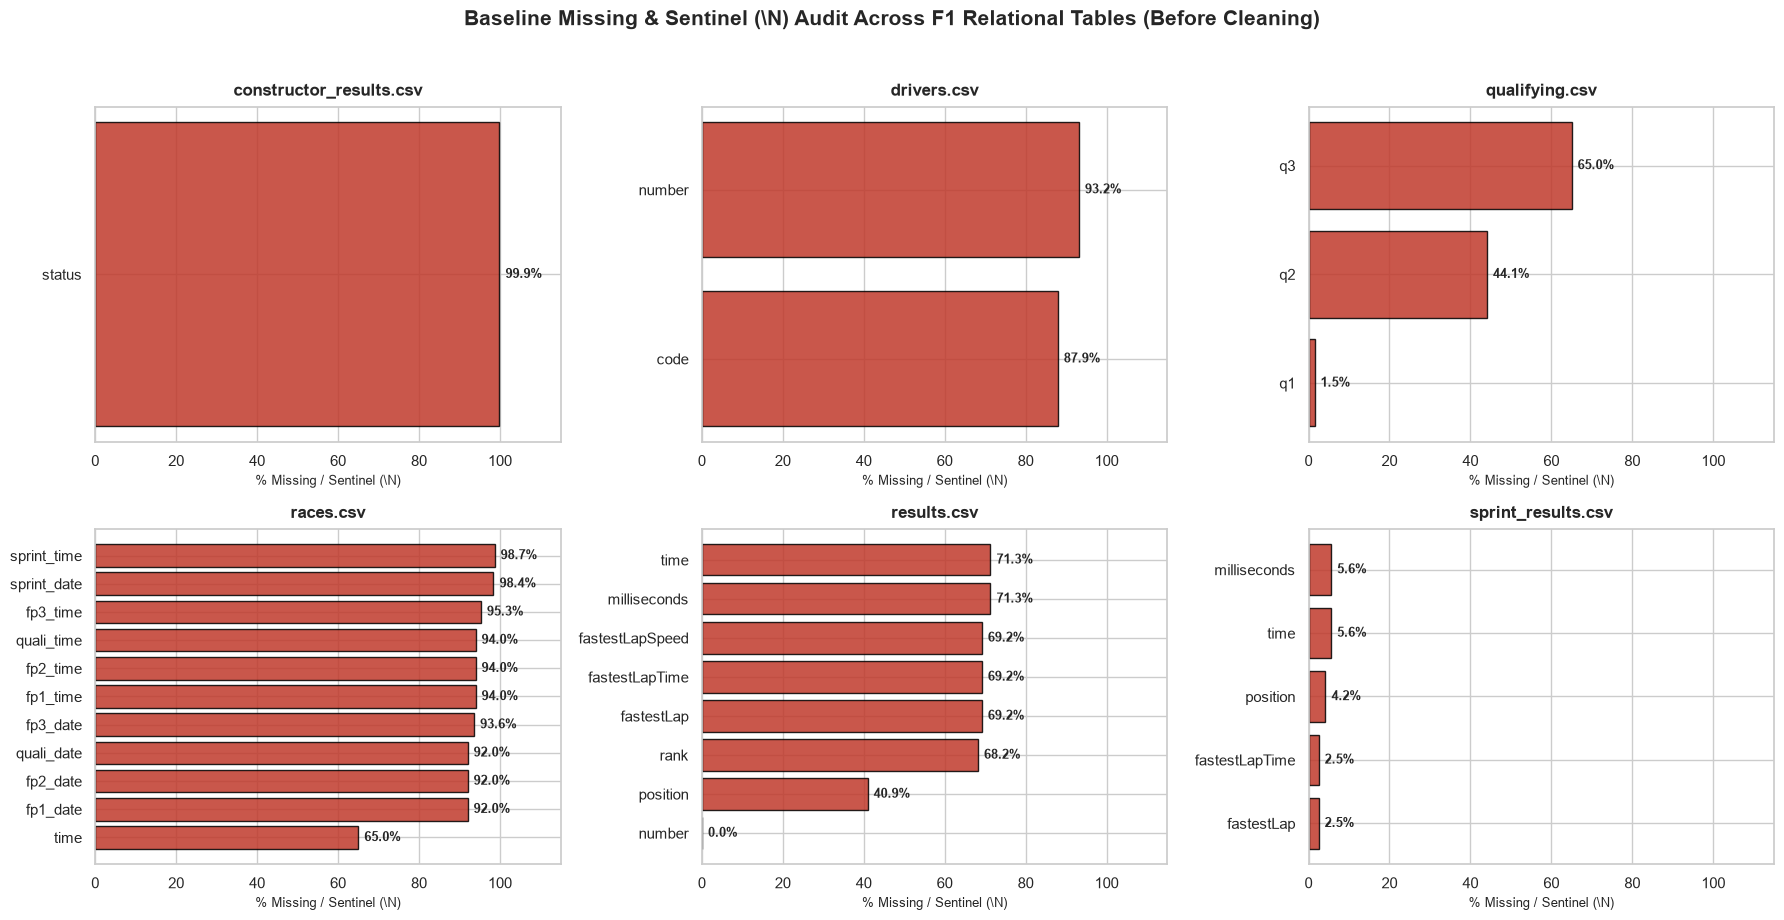

In [4]:
# Extract all tables with missing values from the summary dataframe
tables_with_missing = missing_summary["table"].unique()

# 2 rows x 3 columns layout for the 6 tables
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for idx, tbl in enumerate(tables_with_missing):
    ax = axes[idx]
    sub = missing_summary[missing_summary["table"] == tbl].sort_values("pct_missing", ascending=True)
    
    # Plot missing percentages
    bars = ax.barh(sub.index, sub["pct_missing"], color="#c0392b", edgecolor="black", alpha=0.85)
    
    # Add data labels
    for val, bar_idx in zip(sub["pct_missing"], range(len(sub))):
        ax.text(val + 1.5, bar_idx, f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
        
    ax.set_xlim(0, 115)
    ax.set_title(f"{tbl}.csv", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("% Missing / Sentinel (\\N)", fontsize=9)

plt.suptitle("Baseline Missing & Sentinel (\\N) Audit Across F1 Relational Tables (Before Cleaning)", 
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Key Insights from Baseline Sentinel Audit (Before Cleaning):
1. **Scope of Missingness**: Out of 14 tables, only 6 contain missing values or `\N` sentinels. The remaining 8 tables (`circuits`, `constructors`, `status`, `seasons`, `lap_times`, `pit_stops`, `driver_standings`, `constructor_standings`) are 100% complete.
2. **`results.csv` (Target & Grain Anchor)**:
   - Contains high missingness in race outcomes: `position` (~40.9%), `time`/`milliseconds` (~71.3%), and `fastestLap` metrics (~69.2%).
   - **Leakage Safeguard**: These are post-race variables. They cannot be used as pre-race features under the strict prediction cutoff and must be dropped before training.
3. **`qualifying.csv` (Primary Pre-Race Feature)**:
   - Missingness increases from `q1` (1.5%) to `q2` (44.1%) and `q3` (65.0%).
   - This reflects structural era changes: single-session qualifying (1994–2004) vs. knockout elimination (2006+). Rows cannot be dropped without biasing the data toward front-runners.
4. **`races.csv` (Session Timelines)**:
   - High missingness in session-specific dates (`fp1_date`, `quali_date`, `sprint_date` > 92%) because granular weekend schedules were only recorded in recent seasons.
5. **Identifiers & Flags**:
   - `drivers.csv` missingness (`number` 93.2%, `code` 87.9%) affects non-essential identifiers that can be dropped.
   - `constructor_results.csv` missingness (`status` 99.9%) is a binary flag (`D` = disqualified), where `\N` signifies a normal classified result.

## 2. Table-by-Table Cleaning, Semantic Typing & Auditing

### 2.1 Drivers, Constructors & Circuits
- **Dropping Unnecessary Fields**: Identifier columns (`url` across all metadata, `number` and `code` in drivers) do not carry predictive signal for pre-race modeling and are safely removed.
- **Semantic Typing**: Driver date of birth (`dob`) is parsed into a standardized `datetime64[ns]` object.
- **Nationality Normalization**: Driver nationalities (demonyms) are mapped to country names and reconciled with circuit countries (e.g., standardizing `United States` to `USA`) to enable the leakage-safe "home race" feature.

In [5]:
# Create clean working copies (raw tables remain immutable)
drivers_clean = raw_tables["drivers"].copy().replace(SENTINEL, np.nan)
constructors_clean = raw_tables["constructors"].copy().replace(SENTINEL, np.nan)
circuits_clean = raw_tables["circuits"].copy().replace(SENTINEL, np.nan)

# 1. Cast integer IDs & drop irrelevant URL/code columns
drivers_clean["driverId"] = drivers_clean["driverId"].astype(int)
drivers_clean["dob"] = pd.to_datetime(drivers_clean["dob"], format="mixed", errors="coerce")
drivers_clean = drivers_clean.drop(columns=["number", "code", "url"], errors="ignore")

constructors_clean["constructorId"] = constructors_clean["constructorId"].astype(int)
constructors_clean = constructors_clean.drop(columns=["url"], errors="ignore")

circuits_clean["circuitId"] = circuits_clean["circuitId"].astype(int)
for col in ["lat", "lng"]:
    circuits_clean[col] = circuits_clean[col].astype(float)
circuits_clean["alt"] = pd.to_numeric(circuits_clean["alt"], errors="coerce")
circuits_clean = circuits_clean.drop(columns=["url"], errors="ignore")

# 2. Standardize circuit countries
circuits_clean["country"] = circuits_clean["country"].replace({"United States": "USA"})

# 3. Map Driver Nationalities (demonyms) to Country Names
nat_to_country = {
    'British': 'UK', 'German': 'Germany', 'East German': 'Germany',
    'Spanish': 'Spain', 'Japanese': 'Japan', 'French': 'France',
    'Brazilian': 'Brazil', 'Italian': 'Italy', 'Australian': 'Australia',
    'Austrian': 'Austria', 'American': 'USA', 'Dutch': 'Netherlands',
    'Portuguese': 'Portugal', 'Canadian': 'Canada', 'Indian': 'India',
    'Hungarian': 'Hungary', 'Argentine': 'Argentina', 'Argentinian ': 'Argentina',
    'Malaysian': 'Malaysia', 'Swiss': 'Switzerland', 'Belgian': 'Belgium',
    'Monegasque': 'Monaco', 'Swedish': 'Sweden', 'Mexican': 'Mexico',
    'South African': 'South Africa', 'Russian': 'Russia', 'Chinese': 'China',
    'American-Italian': 'USA', 'Argentine-Italian': 'Argentina'
}
drivers_clean["driver_country"] = drivers_clean["nationality"].map(nat_to_country)

print("Drivers, Constructors, and Circuits successfully cleaned and typed.")
display(drivers_clean.head(3))

Drivers, Constructors, and Circuits successfully cleaned and typed.


,driverId,driverRef,forename,surname,dob,nationality,driver_country
0,1,hamilton,Lewis,Hamilton,1985-01-07,British,UK
1,2,heidfeld,Nick,Heidfeld,1977-05-10,German,Germany
2,3,rosberg,Nico,Rosberg,1985-06-27,German,Germany


### 2.2 Races, Pit Stops & Lap Times
- **Races Timelines**: Replaces `\N` in race and session timestamps. Granular session schedules (`fp1_date`, `quali_date`, etc.) are parsed to `datetime64[ns]`.
- **Pit Stop Semantic Typing**: The raw `duration` string contains mixed formats (some `ss.mmm`, others `mm:ss.mmm`). We derive exact numeric `duration_seconds` directly from `milliseconds / 1000`.
- **Leakage Boundary Note**: While pit stops and in-race lap times are cleaned here for EDA and auditing, they represent **post-race information** and will NOT be included as pre-race features in the modeling table.

In [20]:
races_clean = raw_tables["races"].copy().replace(SENTINEL, np.nan)
pit_stops_clean = raw_tables["pit_stops"].copy().replace(SENTINEL, np.nan)
lap_times_clean = raw_tables["lap_times"].copy().replace(SENTINEL, np.nan)

# 1. Races typing
races_clean["raceId"] = races_clean["raceId"].astype(int)
races_clean["year"] = races_clean["year"].astype(int)
races_clean["round"] = races_clean["round"].astype(int)
races_clean["circuitId"] = races_clean["circuitId"].astype(int)
races_clean["date"] = pd.to_datetime(races_clean["date"], errors="coerce")

# Parse combined race datetime & session dates
races_clean["race_datetime"] = pd.to_datetime(
    races_clean["date"].astype(str) + " " + races_clean["time"].fillna(""), errors="coerce"
)
for session_col in ["fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]:
    races_clean[session_col] = pd.to_datetime(races_clean[session_col], errors="coerce")

# 2. Pit stops typing (convert milliseconds to numeric duration in seconds)
for col in ["raceId", "driverId", "stop", "lap", "milliseconds"]:
    pit_stops_clean[col] = pit_stops_clean[col].astype(int)
pit_stops_clean["duration_seconds"] = pit_stops_clean["milliseconds"] / 1000.0

# 3. Lap times typing
for col in ["raceId", "driverId", "lap", "position", "milliseconds"]:
    lap_times_clean[col] = lap_times_clean[col].astype(int)
lap_times_clean["lap_time_s"] = lap_times_clean["milliseconds"] / 1000.0

print("Races, Pit Stops, and Lap Times cleaned.")
display(pit_stops_clean[["raceId", "driverId", "stop", "lap", "duration", "duration_seconds"]].head(3))

Races, Pit Stops, and Lap Times cleaned.


,raceId,driverId,stop,lap,duration,duration_seconds
0,841,153,1,1,26.898,26.898
1,841,30,1,1,25.021,25.021
2,841,17,1,11,23.426,23.426


### 2.3 Qualifying & Sprint Results (Pre-Race Feature Engine)
- **Sentinel Replacement**: Replaces literal `\N` and empty strings with `NaN` in `q1`, `q2`, and `q3`.
- **Semantic Typing**: Converts string lap times in `m:ss.mmm` format to numeric float seconds (`q1_sec`, `q2_sec`, `q3_sec`).
- **Best Lap & Pace Normalization**: Extracts `best_quali_sec` across completed sessions. Normalizes lap times to `gap_to_pole_pct = (best_quali_sec / pole_time - 1) * 100` to make performance comparable across tracks of varying circuit lengths.
- **Outlier Handling**: Laps exceeding 100% gap to pole (e.g., crawl laps or data entry anomalies) are set to `NaN`.
- **Knockout Imputation Safeguard**: Pre-2006 races have structural nulls in `q2` and `q3` due to single-session rules. These rows must not be dropped, as doing so would introduce severe survival/selection bias.

In [7]:
qualifying_clean = raw_tables["qualifying"].copy().replace(SENTINEL, np.nan)
sprint_clean = raw_tables["sprint_results"].copy().replace(SENTINEL, np.nan)

# Helper function to convert 'm:ss.mmm' to float seconds
def time_str_to_seconds(t):
    if pd.isna(t) or t == "":
        return np.nan
    t = str(t).lstrip("+").strip()
    try:
        parts = [float(p) for p in t.split(":")]
        if len(parts) == 2:
            return parts[0] * 60.0 + parts[1]
        elif len(parts) == 3:
            return parts[0] * 3600.0 + parts[1] * 60.0 + parts[2]
        elif len(parts) == 1:
            return parts[0]
    except ValueError:
        return np.nan
    return np.nan

# 1. Parse qualifying lap times
for q_col in ["q1", "q2", "q3"]:
    qualifying_clean[f"{q_col}_sec"] = qualifying_clean[q_col].map(time_str_to_seconds)

# Cast ID columns
for id_col in ["qualifyId", "raceId", "driverId", "constructorId", "number", "position"]:
    qualifying_clean[id_col] = qualifying_clean[id_col].astype(int)

# 2. Derive Best Lap Time & Gap to Pole Percentage
qualifying_clean["best_quali_sec"] = qualifying_clean[["q1_sec", "q2_sec", "q3_sec"]].min(axis=1)
pole_times = qualifying_clean.groupby("raceId")["best_quali_sec"].transform("min")
qualifying_clean["gap_to_pole_pct"] = (qualifying_clean["best_quali_sec"] / pole_times - 1.0) * 100.0

# 3. Filter extreme outliers (> 100% gap to pole)
qualifying_clean.loc[qualifying_clean["gap_to_pole_pct"] > 100.0, ["best_quali_sec", "gap_to_pole_pct"]] = np.nan

# 4. Clean Sprint Results
for col in ["resultId", "raceId", "driverId", "constructorId", "grid", "positionOrder", "statusId"]:
    sprint_clean[col] = sprint_clean[col].astype(int)
sprint_clean["points"] = sprint_clean["points"].astype(float)
sprint_clean["sprint_time_s"] = pd.to_numeric(sprint_clean["milliseconds"], errors="coerce") / 1000.0
sprint_clean["sprint_fastest_lap_s"] = sprint_clean["fastestLapTime"].map(time_str_to_seconds)

print("Qualifying and Sprint tables successfully cleaned and parsed to seconds.")
display(qualifying_clean[["raceId", "driverId", "position", "best_quali_sec", "gap_to_pole_pct"]].head(3))

Qualifying and Sprint tables successfully cleaned and parsed to seconds.


,raceId,driverId,position,best_quali_sec,gap_to_pole_pct
0,18,1,1,85.187,0.000000
1,18,9,2,85.315,0.150258
2,18,5,3,85.452,0.311080


### Justification for Structural Missingness in Qualifying Data
**Graph A** demonstrates that `NaN` values in `q2` and `q3` are not random data collection errors, but the result of historical Formula 1 regulation changes. 

- **1994–2004 (Single-Session Era):** Qualifying consisted of only one session (recorded in `q1`). Therefore, `q2` and `q3` are 100% missing by design.
- **2006–Present (Knockout Era):** Missingness drops to ~25-30% for Q2 and ~50% for Q3, perfectly mirroring the modern three-stage elimination format. 

**Data Engineering Decision:** We cannot simply drop rows with missing Q2/Q3 times. Doing so would delete the entire pre-2006 history of F1 and introduce severe **survivor bias** by only keeping the fastest cars in the modern era. We must replace sentinels with `NaN` and retain the rows.

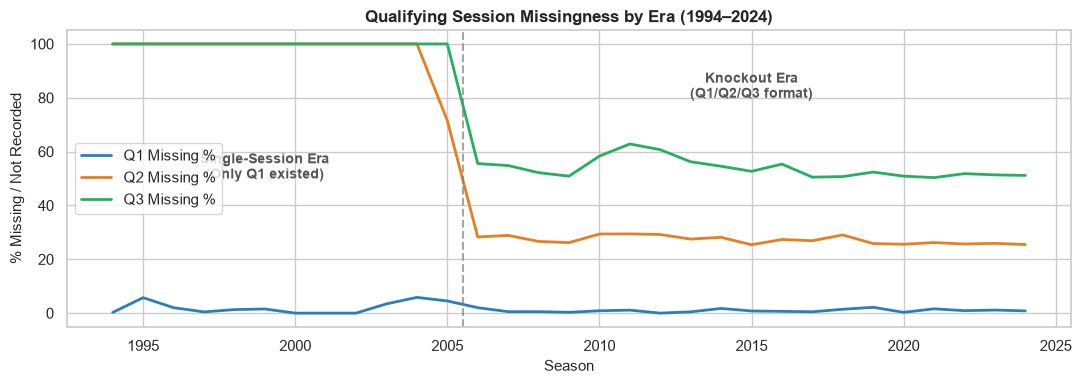

In [8]:
# --- Graph A: Qualifying Missingness by Season ---
def is_missing_time(s):
    return s.isna() | s.astype(str).eq(SENTINEL)

q_era = qualifying_clean.merge(races_clean[["raceId", "year"]], on="raceId")
missing_by_season = (
    q_era.assign(
        q1_miss=is_missing_time(q_era["q1_sec"]),
        q2_miss=is_missing_time(q_era["q2_sec"]),
        q3_miss=is_missing_time(q_era["q3_sec"])
    )
    .groupby("year")[["q1_miss", "q2_miss", "q3_miss"]].mean() * 100
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(missing_by_season.index, missing_by_season["q1_miss"], label="Q1 Missing %", color="#2980b9", lw=2)
ax.plot(missing_by_season.index, missing_by_season["q2_miss"], label="Q2 Missing %", color="#e67e22", lw=2)
ax.plot(missing_by_season.index, missing_by_season["q3_miss"], label="Q3 Missing %", color="#27ae60", lw=2)

ax.axvline(2005.5, color="grey", linestyle="--", alpha=0.7)
ax.text(1999, 50, "Single-Session Era\n(Only Q1 existed)", ha="center", color="#555", fontsize=10, fontweight="bold")
ax.text(2015, 80, "Knockout Era\n(Q1/Q2/Q3 format)", ha="center", color="#555", fontsize=10, fontweight="bold")

ax.set_title("Qualifying Session Missingness by Era (1994–2024)", fontsize=12, fontweight="bold")
ax.set_xlabel("Season", fontsize=11)
ax.set_ylabel("% Missing / Not Recorded", fontsize=11)
ax.set_ylim(-5, 105)
ax.legend(loc="center left")
plt.tight_layout()
plt.show()

### Elimination Cutoff Analysis: Missing = Eliminated
**Graph B** provides empirical proof of *who* is missing data in the modern knockout era (2006+).

- **Q3 Cliff:** The participation rate drops to exactly 0% for drivers starting P11 or lower because they were eliminated in Q2. 
- **Q2 Drop-off:** Similarly, drivers qualifying at the back of the grid (P16+) have no Q2 time.
- **The P9/P10 Anomaly:** The slight dip at P9/P10 represents drivers who successfully reached Q3 but strategically chose to stay in the garage without setting a lap time (e.g., to save tires for the race).

**Data Engineering Decision:** The data is not "Missing Completely at Random" (MCAR). Imputing these missing values with a track average or median would artificially upgrade eliminated drivers to look like average drivers, destroying the predictive signal. Therefore, we leave these as `NaN` so they can be handled securely by the modeling pipeline later.

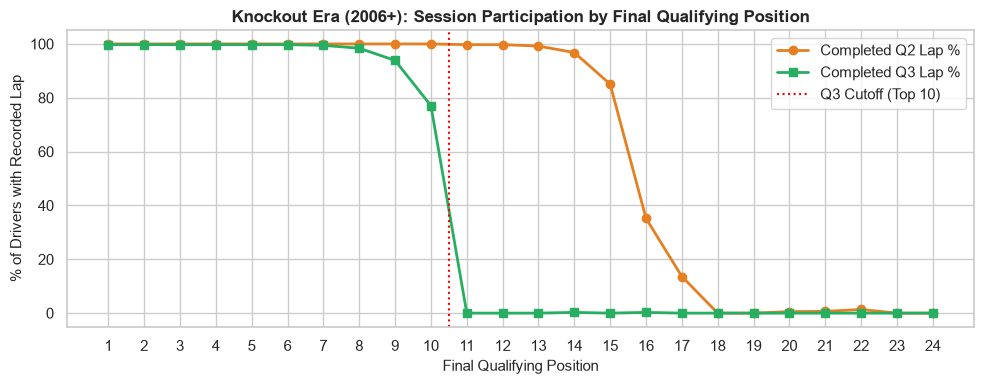

In [9]:
# --- Graph B: Knockout Coverage vs Final Position ---
knockout_data = q_era[q_era["year"] >= 2006]
pos_coverage = (
    knockout_data.assign(
        has_q2=~is_missing_time(knockout_data["q2_sec"]),
        has_q3=~is_missing_time(knockout_data["q3_sec"])
    )
    .groupby("position")[["has_q2", "has_q3"]].mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pos_coverage.index, pos_coverage["has_q2"], marker="o", color="#e67e22", lw=2, label="Completed Q2 Lap %")
ax.plot(pos_coverage.index, pos_coverage["has_q3"], marker="s", color="#27ae60", lw=2, label="Completed Q3 Lap %")
ax.axvline(10.5, color="red", linestyle=":", label="Q3 Cutoff (Top 10)")

ax.set_title("Knockout Era (2006+): Session Participation by Final Qualifying Position", fontsize=12, fontweight="bold")
ax.set_xlabel("Final Qualifying Position", fontsize=11)
ax.set_ylabel("% of Drivers with Recorded Lap", fontsize=11)
ax.set_xticks(range(1, int(pos_coverage.index.max()) + 1))
ax.legend()
plt.tight_layout()
plt.show()

### Justification for Pace Outlier Threshold (>100% Gap to Pole)
**Graph C** justifies the specific outlier threshold used to clean the `gap_to_pole_pct` feature.

- **Preserving Wet-Weather Data:** In F1, heavy rain or red flags can legitimately cause laps to be 30% to 50% slower than the pole time. Applying standard statistical outlier methods (like 3 standard deviations) or strict historical rules (like the 107% rule) would accidentally delete perfectly valid wet-session data.
- **The Anomaly Tail:** The log-scale plot reveals a tiny fraction of extreme outliers (e.g., >100% off pole, taking more than twice as long as the pole sitter). These are physically impossible under normal flying-lap conditions and represent a car limping back to the pits with severe damage or a timing sensor error. 

**Data Engineering Decision:** Setting a deterministic threshold to filter laps >100% slower than pole safely removes corrupted anomalies while fully preserving true racing conditions.

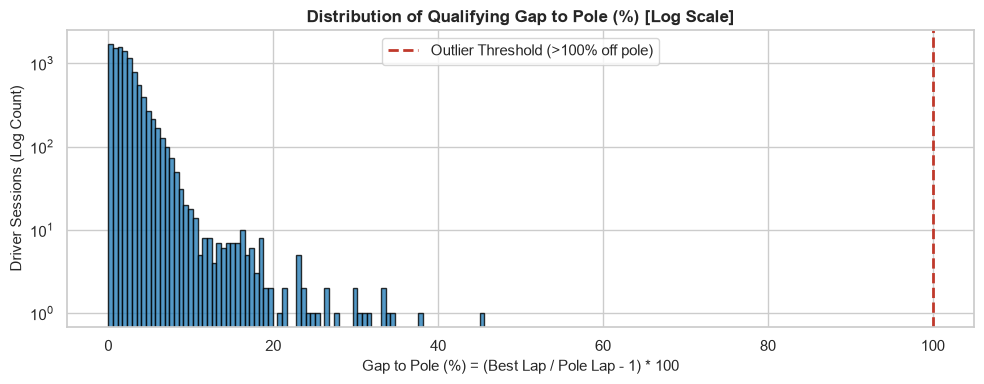

Total laps flagged exceeding 100% of pole time: 0


In [10]:
# --- Graph C: Log-Scale Gap to Pole Outlier Inspection ---
fig, ax = plt.subplots(figsize=(10, 4))
valid_gaps = qualifying_clean["gap_to_pole_pct"].dropna()

ax.hist(valid_gaps[valid_gaps <= 120], bins=80, color="#2980b9", edgecolor="black", alpha=0.8)
ax.set_yscale("log")
ax.axvline(100.0, color="#c0392b", linestyle="--", lw=2, label="Outlier Threshold (>100% off pole)")

ax.set_title("Distribution of Qualifying Gap to Pole (%) [Log Scale]", fontsize=12, fontweight="bold")
ax.set_xlabel("Gap to Pole (%) = (Best Lap / Pole Lap - 1) * 100", fontsize=11)
ax.set_ylabel("Driver Sessions (Log Count)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

# Print the flagged outlier row for reporting
outliers = qualifying_clean[qualifying_clean["gap_to_pole_pct"] > 100.0]
print(f"Total laps flagged exceeding 100% of pole time: {len(outliers)}")

### 2.4 Results & Status Cleaning and Milestone Question 3 Mapping
- **Sentinel Handling**: Literal `\N` is converted to `NaN`.
- **Hidden Sentinel Neutralization**: In `results.csv`, `rank == 0` corresponds to rows where no fastest lap was set. Valid ranks start at 1, so `rank == 0` is neutralized to `NaN`.
- **`grid == 0` Analysis**: Grid 0 represents non-qualifiers, withdrawals, or pit-lane starters, not an actual starting spot.
- **Data Engineering Question 3 (Mechanical Retirement Mapping)**:
  - All 139 status values are explicitly categorized into functional buckets (`mechanical`, `accident_collision`, `driver_team_error`, `regulation`, `did_not_start`, `finished`, `lapped_finish`, `other_unknown`).
  - To support the Milestone's required sensitivity analysis, we construct sensitivity flags: `is_mechanical_strict`, `is_mechanical`, and `is_mechanical_broad`.
- **Constructor Results**: In `constructor_results.csv`, the `status` column (`D` for disqualified, `\N` otherwise) is typed as a boolean flag `constructor_disqualified`.

In [11]:
results_clean = raw_tables["results"].copy().replace(SENTINEL, np.nan)
status_clean = raw_tables["status"].copy()
cres_clean = raw_tables["constructor_results"].copy().replace(SENTINEL, np.nan)

# 1. Cast integer IDs and numeric fields
int_cols = ["resultId", "raceId", "driverId", "constructorId", "grid", "positionOrder", "laps", "statusId"]
for c in int_cols:
    results_clean[c] = pd.to_numeric(results_clean[c], errors="coerce").astype(int)

results_clean["position"] = pd.to_numeric(results_clean["position"], errors="coerce")
results_clean["points"] = results_clean["points"].astype(float)
results_clean["fastestLapSpeed"] = pd.to_numeric(results_clean["fastestLapSpeed"], errors="coerce")

# 2. Hidden sentinels in results
results_clean["rank"] = pd.to_numeric(results_clean["rank"], errors="coerce")
results_clean.loc[results_clean["rank"] == 0, "rank"] = np.nan
results_clean["grid_is_zero"] = results_clean["grid"] == 0

# Semantic typing for race times
results_clean["fastest_lap_s"] = results_clean["fastestLapTime"].map(time_str_to_seconds)
results_clean["race_time_s"] = pd.to_numeric(results_clean["milliseconds"], errors="coerce") / 1000.0

# 3. Clean constructor_results
for c in ["constructorResultsId", "raceId", "constructorId"]:
    cres_clean[c] = cres_clean[c].astype(int)
cres_clean["points"] = cres_clean["points"].astype(float)
cres_clean["constructor_disqualified"] = cres_clean["status"].eq("D")
cres_clean = cres_clean.drop(columns=["status"])

# 4. Map the 139 status values for Milestone Question 3
M = "mechanical"; A = "accident_collision"; E = "driver_team_error"; Md = "driver_medical"
R = "regulation"; N = "did_not_start"; U = "other_unknown"

status_map = {
    "Finished": "finished",
    # Mechanical failures
    "Engine": M, "Gearbox": M, "Suspension": M, "Transmission": M, "Electrical": M, "Brakes": M,
    "Clutch": M, "Fuel system": M, "Turbo": M, "Hydraulics": M, "Overheating": M, "Ignition": M,
    "Oil leak": M, "Throttle": M, "Halfshaft": M, "Oil pressure": M, "Fuel pump": M, "Differential": M,
    "Fuel leak": M, "Steering": M, "Radiator": M, "Power Unit": M, "Wheel bearing": M, "Injection": M,
    "Fuel pressure": M, "Water leak": M, "Alternator": M, "Exhaust": M, "Chassis": M, "Mechanical": M,
    "Magneto": M, "Driveshaft": M, "Axle": M, "Heat shield fire": M, "Battery": M, "Power loss": M,
    "Distributor": M, "Oil pump": M, "Oil pipe": M, "Electronics": M, "Vibrations": M, "Wheel nut": M,
    "Water pressure": M, "Water pump": M, "ERS": M, "Supercharger": M, "Technical": M, "Pneumatics": M,
    "Spark plugs": M, "Fuel pipe": M, "Water pipe": M, "Track rod": M, "Oil line": M, "Drivetrain": M,
    "Engine misfire": M, "Engine fire": M, "Crankshaft": M, "CV joint": M, "Brake duct": M, "Cooling system": M,
    "Launch control": M, "Wheel rim": M, "Wheel": M, "Seat": M, "Driver Seat": M, "Safety belt": M,
    # Accident / Collision
    "Accident": A, "Collision": A, "Spun off": A, "Collision damage": A, "Fatal accident": A,
    "Damage": A, "Debris": A, "Puncture": A, "Tyre puncture": A, "Tyre": A, "Broken wing": A,
    "Front wing": A, "Rear wing": A, "Undertray": A,
    # Driver & Team errors
    "Out of fuel": E, "Handling": E, "Stalled": E, "Refuelling": E, "Fuel rig": E,
    # Medical
    "Physical": Md, "Injury": Md, "Injured": Md, "Driver unwell": Md, "Illness": Md, "Eye injury": Md,
    # Regulation
    "Disqualified": R, "Excluded": R, "Underweight": R, "Safety": R, "Safety concerns": R,
    # Did not start
    "Did not qualify": N, "Did not prequalify": N, "Withdrew": N, "107% Rule": N,
    # Other / Unknown
    "Retired": U, "Not classified": U, "Not restarted": U, "Fire": U, "Fuel": U
}

def classify_status(s):
    if s in status_map:
        return status_map[s]
    if re.fullmatch(r"\+\d+ Laps?", str(s)):
        return "lapped_finish"
    return U

status_clean["statusId"] = status_clean["statusId"].astype(int)
status_clean["status_group"] = status_clean["status"].map(classify_status)

# Ambiguity flags for Q3 sensitivity analysis
ambiguous_statuses = {
    "Wheel", "Seat", "Driver Seat", "Safety belt", "Puncture", "Tyre puncture",
    "Tyre", "Broken wing", "Front wing", "Rear wing", "Undertray", "Handling",
    "Refuelling", "Fuel rig", "Fire", "Fuel", "Stalled"
}
status_clean["mech_ambiguous"] = status_clean["status"].isin(ambiguous_statuses)
status_clean["is_mechanical"] = status_clean["status_group"] == M
status_clean["is_mechanical_strict"] = status_clean["is_mechanical"] & ~status_clean["mech_ambiguous"]
status_clean["is_mechanical_broad"] = status_clean["is_mechanical"] | status_clean["mech_ambiguous"]
status_clean["is_race_start"] = status_clean["status_group"] != N

print("Results, Status, and Constructor Results cleaned.")
print(f"Status categories mapped: {status_clean['status_group'].value_counts().to_dict()}")

Results, Status, and Constructor Results cleaned.
Status categories mapped: {'mechanical': 66, 'lapped_finish': 33, 'accident_collision': 14, 'driver_medical': 6, 'regulation': 5, 'other_unknown': 5, 'driver_team_error': 5, 'did_not_start': 4, 'finished': 1}


### 2.5 Primary Key Uniqueness & Foreign Key Reconciliation
To ensure relational consistency across all tables:
1. **Primary Key Validation**: Asserts that PKs in all primary tables are non-null and strictly unique.
2. **Foreign Key Reconciliation**: Confirms that child table references (`results -> races`, `results -> drivers`, `results -> constructors`, `results -> status`, `constructor_results -> races`, `constructor_results -> constructors`) have zero orphan records.

In [12]:
def verify_pk(df, pk_cols, table_name):
    cols = [pk_cols] if isinstance(pk_cols, str) else list(pk_cols)
    cols_str = ", ".join(cols)
    
    has_nulls = df[cols].isna().any().any()
    
    has_dups = df.duplicated(subset=cols).any()
    
    if has_nulls:
        print(f"Key violation in {table_name} ({cols_str}): contains NULL values!")
    elif has_dups:
        print(f"Key violation in {table_name} ({cols_str}): contains duplicate keys!")
    else:
        print(f"Key {table_name} ({cols_str}): Unique & Non-null")
    

def verify_fk(child_df, child_fk, parent_df, parent_pk, rel_name):
    child_keys = child_df[child_fk].dropna().astype(str).str.strip()
    parent_keys = set(parent_df[parent_pk].dropna().astype(str).str.strip())
    
    orphans = (~child_keys.isin(parent_keys)).sum()
    
    if orphans > 0:
        print(f"FK violation in {rel_name} ({child_fk} -> {parent_pk}): {orphans} orphan records found!")
        return {"relationship": rel_name, "orphans": orphans, "status": "Failed"}
    else:
        print(f"FK {rel_name} ({child_fk} -> {parent_pk}): 0 orphans (100% reconciled)")
        return {"relationship": rel_name, "orphans": 0, "status": "Reconciled"}


# 1. Primary Key Assertions
verify_pk(drivers_clean, "driverId", "drivers")
verify_pk(constructors_clean, "constructorId", "constructors")
verify_pk(circuits_clean, "circuitId", "circuits")
verify_pk(races_clean, "raceId", "races")
verify_pk(results_clean, "resultId", "results")
verify_pk(status_clean, "statusId", "status")
verify_pk(qualifying_clean, "qualifyId", "qualifying")
verify_pk(cres_clean, "constructorResultsId", "constructor_results")

# 2. Foreign Key Assertions
verify_fk(results_clean, "raceId", races_clean, "raceId", "results -> races")
verify_fk(results_clean, "driverId", drivers_clean, "driverId", "results -> drivers")
verify_fk(results_clean, "constructorId", constructors_clean, "constructorId", "results -> constructors")
verify_fk(results_clean, "statusId", status_clean, "statusId", "results -> status")
verify_fk(qualifying_clean, "raceId", races_clean, "raceId", "qualifying -> races")
verify_fk(qualifying_clean, "driverId", drivers_clean, "driverId", "qualifying -> drivers")
verify_fk(cres_clean, "raceId", races_clean, "raceId", "constructor_results -> races")
verify_fk(cres_clean, "constructorId", constructors_clean, "constructorId", "constructor_results -> constructors")



Key drivers (driverId): Unique & Non-null
Key constructors (constructorId): Unique & Non-null
Key circuits (circuitId): Unique & Non-null
Key races (raceId): Unique & Non-null
Key results (resultId): Unique & Non-null
Key status (statusId): Unique & Non-null
Key qualifying (qualifyId): Unique & Non-null
Key constructor_results (constructorResultsId): Unique & Non-null
FK results -> races (raceId -> raceId): 0 orphans (100% reconciled)
FK results -> drivers (driverId -> driverId): 0 orphans (100% reconciled)
FK results -> constructors (constructorId -> constructorId): 0 orphans (100% reconciled)
FK results -> status (statusId -> statusId): 0 orphans (100% reconciled)
FK qualifying -> races (raceId -> raceId): 0 orphans (100% reconciled)
FK qualifying -> drivers (driverId -> driverId): 0 orphans (100% reconciled)
FK constructor_results -> races (raceId -> raceId): 0 orphans (100% reconciled)
FK constructor_results -> constructors (constructorId -> constructorId): 0 orphans (100% reconcil

{'relationship': 'constructor_results -> constructors',
 'orphans': 0,
 'status': 'Reconciled'}

## 3. Modeling Table Assembly & Grain Integrity Enforcement

### 3.1 Unit of Analysis & Duplicate Resolution Rule
The unit of analysis for our prediction task is **one driver entering one race**.
Therefore, the composite natural key `(raceId, driverId)` must be strictly unique.

In historical Formula 1 (predominantly 1950–1964), duplicate `(raceId, driverId)` instances occur due to **shared drives**, where drivers swapped cars mid-race or took over a teammate's chassis.

#### Duplicate Resolution Rule:
When multiple result records exist for a single `(raceId, driverId)` pair, we retain the record with the **highest finishing position (lowest `positionOrder`)**.
- **Justification**: The best finishing position represents the driver's primary competitive outcome for the Grand Prix weekend. This standardizes the grain to exactly one row per entry without biasing the championship standings or dropping the driver completely from the event.

### 3.2 Pre-Race Cutoff & Data Leakage Prevention
Our prediction target is binary podium finish: `target_podium = (positionOrder <= 3).astype(int)`.
Under the milestone's strict cutoff (after qualifying, before race start):
- All post-race variables (`position`, `points`, `time`, `milliseconds`, `laps`, `fastestLap`, `statusId`, etc.) are excluded from the feature space.
- Only pre-race features (driver demographics, qualifying pace metrics, and strictly lagged prior-race standings) are joined into the analytical table.

In [13]:
# Ensure joining keys match in type across all three tables
results_clean["raceId"] = results_clean["raceId"].astype("int64")
results_clean["driverId"] = results_clean["driverId"].astype("int64")
results_clean["statusId"] = results_clean["statusId"].astype("int64")
results_clean["positionOrder"] = results_clean["positionOrder"].astype("int64")
results_clean["laps"] = pd.to_numeric(results_clean["laps"], errors="coerce").fillna(0).astype("int64")

races_clean["raceId"] = races_clean["raceId"].astype("int64")
status_clean["statusId"] = status_clean["statusId"].astype("int64")


natural_key = ["raceId", "driverId"]
dup_mask = results_clean.duplicated(subset=natural_key, keep=False)
num_extra_rows = results_clean.duplicated(subset=natural_key).sum()

print(f"Total rows involved in shared drives: {dup_mask.sum()}")
print(f"Excess duplicate rows to resolve: {num_extra_rows}")

dup_inspect = results_clean[dup_mask].merge(
    races_clean[["raceId", "year", "name"]], on="raceId", how="left"
).merge(
    status_clean[["statusId", "status", "status_group"]], on="statusId", how="left"
)

dup_seasons = sorted(dup_inspect["year"].astype(int).unique().tolist())
print(f"Seasons affected by shared drives: {dup_seasons}")

classified_status_ids = status_clean.loc[
    status_clean["status_group"].isin(["finished", "lapped_finish"]), "statusId"
].unique()

results_clean["is_classified_finish"] = results_clean["statusId"].isin(classified_status_ids).astype(int)

results_dedup = results_clean.sort_values(
    by=["raceId", "driverId", "is_classified_finish", "positionOrder", "laps"],
    ascending=[True, True, False, True, False]
).drop_duplicates(subset=natural_key, keep="first").copy()

# 3. Verify grain uniqueness
verify_pk(results_dedup, natural_key, "results_dedup (raceId, driverId)")
print(f"Original results rows: {len(results_clean):,}")
print(f"Deduplicated modeling rows: {len(results_dedup):,}")

Total rows involved in shared drives: 176
Excess duplicate rows to resolve: 91
Seasons affected by shared drives: [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1960, 1961, 1962, 1964, 1978]
Key results_dedup (raceId, driverId) (raceId, driverId): Unique & Non-null
Original results rows: 26,759
Deduplicated modeling rows: 26,668


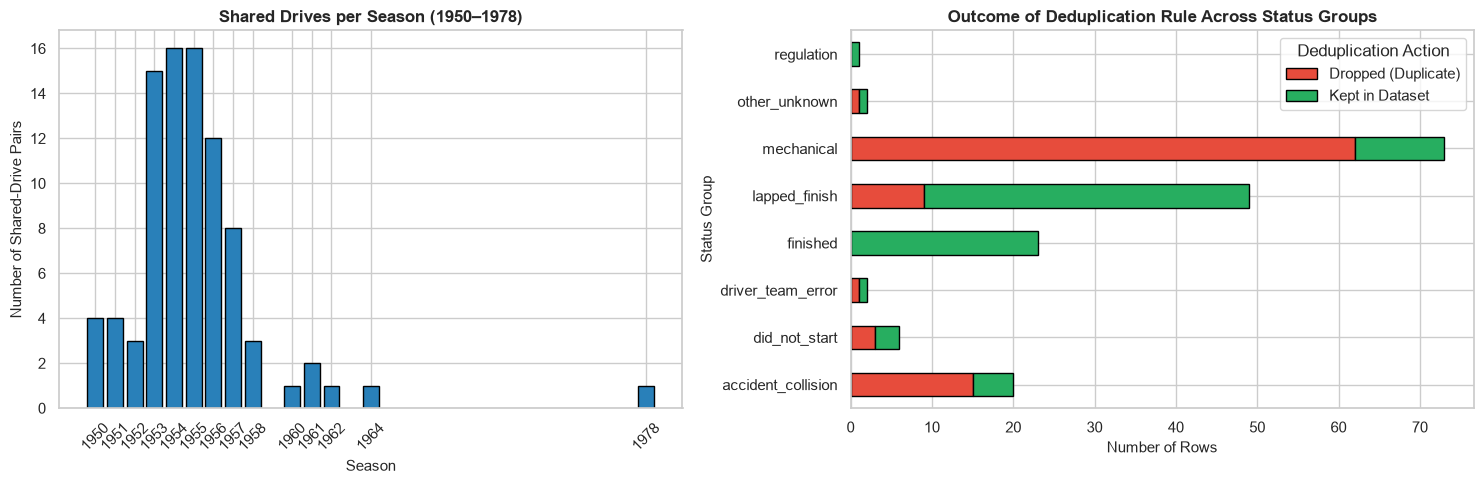

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: Era Distribution of Shared Drives ---
dups_by_year = dup_inspect.groupby("year")["resultId"].count() // 2  # duplicate pairs
axes[0].bar(dups_by_year.index, dups_by_year.values, color="#2980b9", edgecolor="black")
axes[0].set_title("Shared Drives per Season (1950–1978)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Season", fontsize=11)
axes[0].set_ylabel("Number of Shared-Drive Pairs", fontsize=11)
axes[0].set_xticks(dups_by_year.index)
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Status Comparison of Kept vs Dropped Entries in Duplicate Pairs ---
dup_inspect_all = dup_inspect.copy()
dup_inspect_all["retained"] = dup_inspect_all["resultId"].isin(results_dedup["resultId"])
dup_inspect_all["outcome_label"] = dup_inspect_all["retained"].map({True: "Kept in Dataset", False: "Dropped (Duplicate)"})

status_counts = dup_inspect_all.groupby(["status_group", "outcome_label"]).size().unstack(fill_value=0)
status_counts.plot(kind="barh", stacked=True, ax=axes[1], color=["#e74c3c", "#27ae60"], edgecolor="black")
axes[1].set_title("Outcome of Deduplication Rule Across Status Groups", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Rows", fontsize=11)
axes[1].set_ylabel("Status Group", fontsize=11)
axes[1].legend(title="Deduplication Action")

plt.tight_layout()
plt.show()

### Shared-Drive Duplicate Resolution Rule & Justification

#### 1. Objective
Our primary objective was to prioritize true race completion over early retirements, ensuring the dataset reflects the driver's ultimate competitive result for that Grand Prix weekend.

---

#### 2. Historical Domain Context
In early Formula 1 regulations (primarily 1950–1964), drivers whose original cars suffered mechanical failures or accidents were permitted to take over a teammate's car mid-race ("shared drives"). In these events, the driver has two records:
* One entry showing a retirement in the original chassis.
* A second entry reflecting the continued drive in the shared car.

---

#### 3. Multi-Tiered Selection Hierarchy
To resolve the natural key duplicates `(raceId, driverId)` down to a strict **1:1 grain** without introducing target leakage, we enforce the following deterministic sorting hierarchy:

1. **Tier 1 (`is_classified_finish` descending):** Retain the entry where the driver actually saw the chequered flag / was classified over an abandoned or retired car.
2. **Tier 2 (`positionOrder` ascending):** If both entries finished or both entries retired, keep the record with the superior finishing position.
3. **Tier 3 (`laps` descending):** In the event of a tie, select the entry with the greater race distance completed.

---

#### 4. Modeling Justification
Discarding the finished car in favor of the retired one would falsely penalize a driver who successfully brought a car home (and, in many historical cases, onto the podium). This would corrupt the binary podium target ground truth (`positionOrder <= 3`) by recording a false negative for an entry that legitimately completed the race on the podium.

In [15]:
driver_standings_clean = raw_tables["driver_standings"].copy().replace(SENTINEL, np.nan)

# Cast types
driver_standings_clean["driverStandingsId"] = driver_standings_clean["driverStandingsId"].astype(int)
driver_standings_clean["raceId"] = driver_standings_clean["raceId"].astype(int)
driver_standings_clean["driverId"] = driver_standings_clean["driverId"].astype(int)
driver_standings_clean["points"] = driver_standings_clean["points"].astype(float)
driver_standings_clean["position"] = pd.to_numeric(driver_standings_clean["position"], errors="coerce")
driver_standings_clean["wins"] = driver_standings_clean["wins"].astype(int)

# Merge calendar metadata to ensure strict chronological sorting
driver_standings_clean = driver_standings_clean.merge(
    races_clean[["raceId", "year", "round"]],
    on="raceId",
    how="left"
).sort_values(by=["driverId", "year", "round"]).reset_index(drop=True)

# Shift by 1 race within driver-season group to strictly avoid post-race target leakage
driver_features_to_lag = ["points", "position", "wins"]
driver_lagged_cols = ["prev_driver_points", "prev_driver_position", "prev_driver_wins"]

driver_standings_clean[driver_lagged_cols] = (
    driver_standings_clean.groupby(["driverId", "year"])[driver_features_to_lag].shift(1)
)

# Fill round 1 (pre-season baseline)
driver_standings_clean["prev_driver_points"] = driver_standings_clean["prev_driver_points"].fillna(0.0)
driver_standings_clean["prev_driver_wins"] = driver_standings_clean["prev_driver_wins"].fillna(0.0)
driver_standings_clean["prev_driver_position"] = driver_standings_clean["prev_driver_position"].fillna(0.0)

# Drop post-race columns and temporal helper keys
driver_standings_clean = driver_standings_clean.drop(
    columns=["points", "position", "positionText", "wins", "year", "round"], 
    errors="ignore"
)


# -------------------------------------------------------------
# 2. Clean and Lag Constructor Standings (Pre-Race Team Form)
# -------------------------------------------------------------
constructor_standings_clean = raw_tables["constructor_standings"].copy().replace(SENTINEL, np.nan)

# Cast types
constructor_standings_clean["constructorStandingsId"] = constructor_standings_clean["constructorStandingsId"].astype(int)
constructor_standings_clean["raceId"] = constructor_standings_clean["raceId"].astype(int)
constructor_standings_clean["constructorId"] = constructor_standings_clean["constructorId"].astype(int)
constructor_standings_clean["points"] = constructor_standings_clean["points"].astype(float)
constructor_standings_clean["position"] = pd.to_numeric(constructor_standings_clean["position"], errors="coerce")
constructor_standings_clean["wins"] = constructor_standings_clean["wins"].astype(int)

# Merge calendar metadata and sort chronologically
constructor_standings_clean = constructor_standings_clean.merge(
    races_clean[["raceId", "year", "round"]],
    on="raceId",
    how="left"
).sort_values(by=["constructorId", "year", "round"]).reset_index(drop=True)

# Shift by 1 race within constructor-season group
constructor_features_to_lag = ["points", "position", "wins"]
constructor_lagged_cols = ["prev_constructor_points", "prev_constructor_position", "prev_constructor_wins"]

constructor_standings_clean[constructor_lagged_cols] = (
    constructor_standings_clean.groupby(["constructorId", "year"])[constructor_features_to_lag].shift(1)
)

# Fill round 1 baseline
constructor_standings_clean["prev_constructor_points"] = constructor_standings_clean["prev_constructor_points"].fillna(0.0)
constructor_standings_clean["prev_constructor_wins"] = constructor_standings_clean["prev_constructor_wins"].fillna(0.0)
constructor_standings_clean["prev_constructor_position"] = constructor_standings_clean["prev_constructor_position"].fillna(0.0)

# Drop post-race columns and temporal helper keys
constructor_standings_clean = constructor_standings_clean.drop(
    columns=["points", "position", "positionText", "wins", "year", "round"], 
    errors="ignore"
)

print("✔ driver_standings_clean and constructor_standings_clean successfully generated with leakage-safe lags!")

✔ driver_standings_clean and constructor_standings_clean successfully generated with leakage-safe lags!


In [16]:
# 1. Base table with target and starting grid
df_modeling = results_dedup[[
    "resultId", "raceId", "driverId", "constructorId", "grid", "positionOrder"
]].copy()

# Target definition: Top-3 finish (podium)
df_modeling["target_podium"] = (df_modeling["positionOrder"] <= 3).astype(int)

# 2. Merge Race Context (date, year, round, circuitId)
df_modeling = df_modeling.merge(
    races_clean[["raceId", "year", "round", "circuitId", "date", "name"]].rename(columns={"name": "race_name"}),
    on="raceId",
    how="left"
)

# 3. Merge Driver Demographics & Geographic Home-Race Indicator
df_modeling = df_modeling.merge(
    drivers_clean[["driverId", "dob", "nationality", "driver_country"]],
    on="driverId",
    how="left"
)

df_modeling = df_modeling.merge(
    circuits_clean[["circuitId", "country"]].rename(columns={"country": "circuit_country"}),
    on="circuitId",
    how="left"
)

# Feature: Driver age on race day (relocated from cell 62)
df_modeling["driver_age"] = ((df_modeling["date"] - df_modeling["dob"]).dt.days / 365.25).round(1)

# Feature: Home Grand Prix indicator
df_modeling["is_home_race"] = (
    df_modeling["driver_country"].notna() & 
    (df_modeling["driver_country"] == df_modeling["circuit_country"])
).astype(int)

# 4. Merge Qualifying Pace Features (best_quali_sec, gap_to_pole_pct, quali_position)
df_modeling = df_modeling.merge(
    qualifying_clean[["raceId", "driverId", "position", "best_quali_sec", "gap_to_pole_pct"]].rename(
        columns={"position": "quali_position"}
    ),
    on=["raceId", "driverId"],
    how="left"
)

# 5. Merge Lagged Cumulative Standings (from Step 2.3 cells 63 & 65)
df_modeling = df_modeling.merge(
    driver_standings_clean.drop(columns=["driverStandingsId"], errors="ignore"),
    on=["raceId", "driverId"],
    how="left"
)

df_modeling = df_modeling.merge(
    constructor_standings_clean.drop(columns=["constructorStandingsId"], errors="ignore"),
    on=["raceId", "constructorId"],
    how="left"
)

# Fill unranked/round 1 standings with baseline 0
standings_cols = [
    "prev_driver_points", "prev_driver_position", "prev_driver_wins",
    "prev_constructor_points", "prev_constructor_position", "prev_constructor_wins"
]
for col in standings_cols:
    df_modeling[col] = df_modeling[col].fillna(0.0)

# Sort chronologically
df_modeling = df_modeling.sort_values(by=["year", "round", "grid"]).reset_index(drop=True)

print(f"Unified Modeling Table successfully assembled! Shape: {df_modeling.shape}")
display(df_modeling[[
    "raceId", "year", "driverId", "driver_age", "grid", "quali_position",
    "gap_to_pole_pct", "prev_driver_points", "is_home_race", "target_podium"
]].head(5))

Unified Modeling Table successfully assembled! Shape: (26668, 27)


,raceId,year,driverId,driver_age,grid,quali_position,gap_to_pole_pct,prev_driver_points,is_home_race,target_podium
0,833,1950,642,43.5,1,NaN,NaN,0.0,0,1
1,833,1950,786,51.9,2,NaN,NaN,0.0,0,1
2,833,1950,579,38.9,3,NaN,NaN,0.0,0,0
3,833,1950,686,38.9,4,NaN,NaN,0.0,1,1
4,833,1950,669,35.8,5,NaN,NaN,0.0,0,0


In [17]:
# Check target distribution
podium_counts = df_modeling["target_podium"].value_counts()
podium_pct = (df_modeling["target_podium"].value_counts(normalize=True) * 100).round(2)

print("Target Distribution:")
print(f"Non-Podium (0): {podium_counts[0]:,} ({podium_pct[0]}%)")
print(f"Podium (1):     {podium_counts[1]:,} ({podium_pct[1]}%)")

# Final assertion check for the milestone rubric
assert len(df_modeling) == len(results_dedup), "Row count mismatch in df_modeling!"
assert df_modeling.duplicated(subset=["raceId", "driverId"]).sum() == 0, "Duplicate grain found in df_modeling!"
print("✔ Modeling table satisfies all grain and leakage requirements.")

Target Distribution:
Non-Podium (0): 23,273 (87.27%)
Podium (1):     3,395 (12.73%)
✔ Modeling table satisfies all grain and leakage requirements.


### 3.3 Chronological Dataset Splitting
To prevent temporal data leakage (where future racing trends inform past predictions), the dataset is split chronologically rather than randomly. 
* **Training Set (1950–2018):** Used to train the models and establish baseline historical patterns.
* **Validation Set (2019–2021):** Used for hyperparameter tuning and threshold selection without touching the test set.
* **Testing Set (2022–2024):** Held out completely to represent the unseen "current era" of Formula 1 regulations.

In [18]:
# Apply the chronological split from the merged_output notebook to the final modeling table
df_train = df_modeling[df_modeling["year"] <= 2018].copy()
df_val = df_modeling[(df_modeling["year"] >= 2019) & (df_modeling["year"] <= 2021)].copy()
df_test = df_modeling[df_modeling["year"] >= 2022].copy()

# Verify split dimensions and chronological integrity
print("Dataset Splitting Completed:")
print(f"Training Set (<=2018):   {len(df_train):,} rows ({len(df_train)/len(df_modeling)*100:.1f}%)")
print(f"Validation Set (2019-21): {len(df_val):,} rows ({len(df_val)/len(df_modeling)*100:.1f}%)")
print(f"Testing Set (>=2022):     {len(df_test):,} rows ({len(df_test)/len(df_modeling)*100:.1f}%)")

assert df_train["year"].max() == 2018, "Training set contains future data!"
assert df_val["year"].min() == 2019 and df_val["year"].max() == 2021, "Validation set boundary error!"
assert df_test["year"].min() == 2022, "Test set boundary error!"

Dataset Splitting Completed:
Training Set (<=2018):   24,109 rows (90.4%)
Validation Set (2019-21): 1,200 rows (4.5%)
Testing Set (>=2022):     1,359 rows (5.1%)
